In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [2]:
df = pd.read_csv('data/interim/processed_profit_data.csv')
df.head(10)

,items_purchased,product_id,product_name,primary_product_id,is_primary_item,utm_source,utm_campaign,utm_content,device_type,http_referer,is_repeat_session,year,month,day,quater,hour,profit
0,4,4,The Hudson River Mini bear,3,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,0,2014,6,16,2,5,104.0
1,4,1,The Original Mr. Fuzzy,3,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,0,2015,2,2,1,2,124.0
2,2,1,The Original Mr. Fuzzy,1,1,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,0,2014,11,19,4,15,61.0
3,2,2,The Forever Love Bear,2,1,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,0,2013,9,4,3,9,75.0
4,2,4,The Hudson River Mini bear,4,1,unknown,unknown,unknown,desktop,https://www.gsearch.com,1,2014,12,31,4,2,41.0
5,2,1,The Original Mr. Fuzzy,1,1,unknown,unknown,unknown,desktop,https://www.gsearch.com,0,2015,1,12,1,11,61.0
6,2,1,The Original Mr. Fuzzy,1,1,bsearch,nonbrand,b_ad_1,desktop,https://www.bsearch.com,0,2014,10,15,4,15,61.0
7,2,1,The Original Mr. Fuzzy,1,1,bsearch,nonbrand,b_ad_1,desktop,https://www.bsearch.com,0,2012,12,17,4,15,61.0
8,4,1,The Original Mr. Fuzzy,1,1,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,0,2014,11,14,4,17,102.0
9,2,1,The Original Mr. Fuzzy,1,1,bsearch,nonbrand,b_ad_1,desktop,https://www.bsearch.com,0,2015,2,16,1,10,61.0


In [3]:
df.shape

(280175, 17)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 280175 entries, 0 to 280174
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   items_purchased     280175 non-null  int64  
 1   product_id          280175 non-null  int64  
 2   product_name        280175 non-null  object 
 3   primary_product_id  280175 non-null  int64  
 4   is_primary_item     280175 non-null  int64  
 5   utm_source          280175 non-null  object 
 6   utm_campaign        280175 non-null  object 
 7   utm_content         280175 non-null  object 
 8   device_type         280175 non-null  object 
 9   http_referer        280175 non-null  object 
 10  is_repeat_session   280175 non-null  int64  
 11  year                280175 non-null  int64  
 12  month               280175 non-null  int64  
 13  day                 280175 non-null  int64  
 14  quater              280175 non-null  int64  
 15  hour                280175 non-nul

In [5]:
df.isnull().sum()

items_purchased       0
product_id            0
product_name          0
primary_product_id    0
is_primary_item       0
utm_source            0
utm_campaign          0
utm_content           0
device_type           0
http_referer          0
is_repeat_session     0
year                  0
month                 0
day                   0
quater                0
hour                  0
profit                0
dtype: int64

In [6]:
categorical_cols = [
    'product_name', 'utm_source', 'utm_campaign', 
    'utm_content', 'device_type', 'http_referer'
]


numerical_cols = [
    'items_purchased', 'product_id', 'primary_product_id', 
    'is_primary_item', 'is_repeat_session', 'year', 
    'month', 'day', 'quater', 'hour'
]

In [7]:
# X là các cột đặc trưng (bỏ cột profit)
X = df.drop(columns=['profit'])

# y là biến mục tiêu
y = df['profit']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train.shape, X_test.shape

((224140, 16), (56035, 16))

In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numerical_cols)
    ]
)

In [10]:
def evaluate_regression_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

In [11]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

results = []
trained_models = {}

for model_name, estimator in models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", estimator)
        ]
    )

    pipeline.fit(X_train, y_train)

    metrics = evaluate_regression_model(pipeline, X_test, y_test)
    metrics["model"] = model_name

    results.append(metrics)
    trained_models[model_name] = pipeline

metrics_df = pd.DataFrame(results)
metrics_df

,MAE,MSE,RMSE,R2,model
0,3.166941,36.768476,6.063702,0.948723,Linear Regression
1,3.166988,36.768470,6.063701,0.948723,Ridge Regression
2,3.169448,36.782770,6.064880,0.948703,Lasso Regression
3,2.168493,29.102020,5.394629,0.959415,Random Forest
4,2.386478,30.500866,5.522759,0.957464,Gradient Boosting


In [12]:
metrics_df = metrics_df.sort_values(by="RMSE", ascending=True)
metrics_df

,MAE,MSE,RMSE,R2,model
3,2.168493,29.102020,5.394629,0.959415,Random Forest
4,2.386478,30.500866,5.522759,0.957464,Gradient Boosting
1,3.166988,36.768470,6.063701,0.948723,Ridge Regression
0,3.166941,36.768476,6.063702,0.948723,Linear Regression
2,3.169448,36.782770,6.064880,0.948703,Lasso Regression


In [13]:
metrics_df.to_csv('reports/metrics/profit_prediction_metrics.csv', index=False)

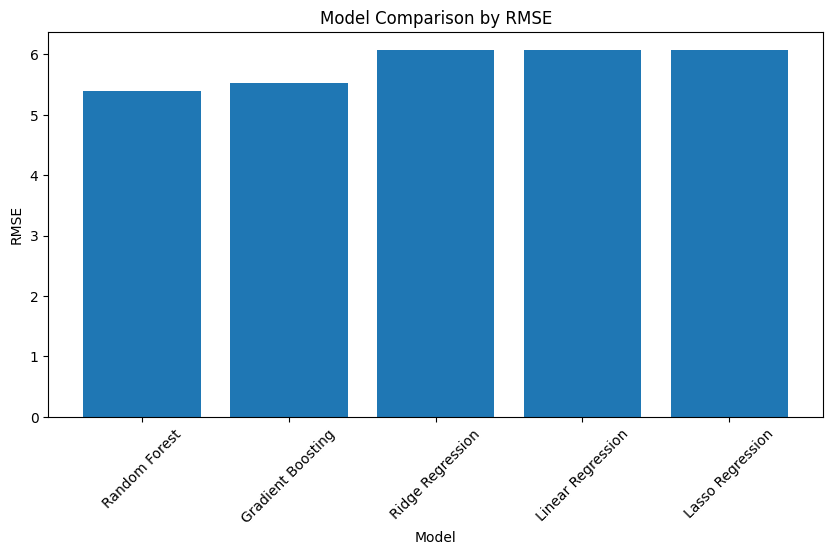

In [14]:
plt.figure(figsize=(10, 5))
plt.bar(metrics_df["model"], metrics_df["RMSE"])
plt.title("Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.show()

In [15]:
best_model_name = metrics_df.iloc[0]["model"]
best_model = trained_models[best_model_name]


In [16]:
best_model_name

'Random Forest'

In [20]:
# save model best_model
joblib.dump(best_model, "ml/models/profit_prediction_model.pkl")

['ml/models/profit_prediction_model.pkl']

In [21]:
# load models from ml/models/profit_prediction_model.pkl
model = joblib.load("ml/models/profit_prediction_model.pkl")

In [22]:
sample_input = pd.DataFrame([
    {
        "items_purchased": 1,
        "product_id": 1,
        "product_name": "The Original Mr. Fuzzy",
        "primary_product_id": 1,
        "is_primary_item": 1,
        "utm_source": "gsearch",
        "utm_campaign": "nonbrand",
        "utm_content": "g_ad_1",
        "device_type": "desktop",
        "http_referer": "https://www.gsearch.com",
        "is_repeat_session": 0,
        "year": 2013,
        "month": 5,
        "day": 12,
        "quater": 2,
        "hour": 14
    }
])

In [23]:
prediction = model.predict(sample_input)[0]

In [24]:
print(f"Predicted profit: ${prediction:.2f}")

Predicted profit: $61.00


In [25]:
# analyze prediction errors

y_pred = model.predict(X_test)

error_df = pd.DataFrame({
    "actual_profit": y_test.values,
    "predicted_profit": y_pred,
    "error": y_test.values - y_pred
})

error_df.head()

,actual_profit,predicted_profit,error
0,61.0,61.000000,0.000000
1,124.0,112.748198,11.251802
2,104.0,104.000000,0.000000
3,124.0,124.000000,0.000000
4,61.0,61.000000,0.000000


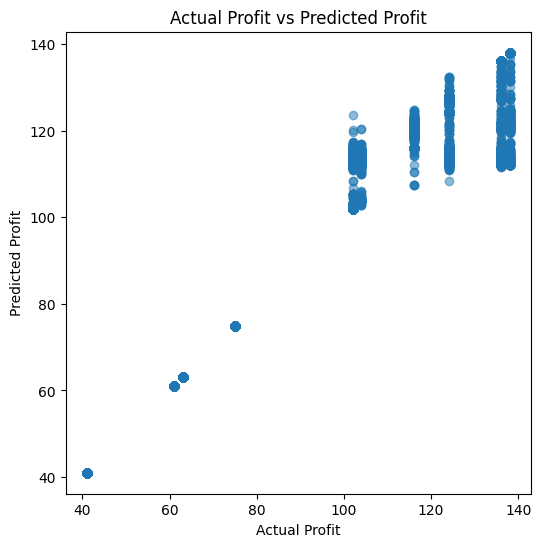

In [26]:
plt.figure(figsize=(6, 6))
plt.scatter(error_df["actual_profit"], error_df["predicted_profit"], alpha=0.5)
plt.title("Actual Profit vs Predicted Profit")
plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.show()

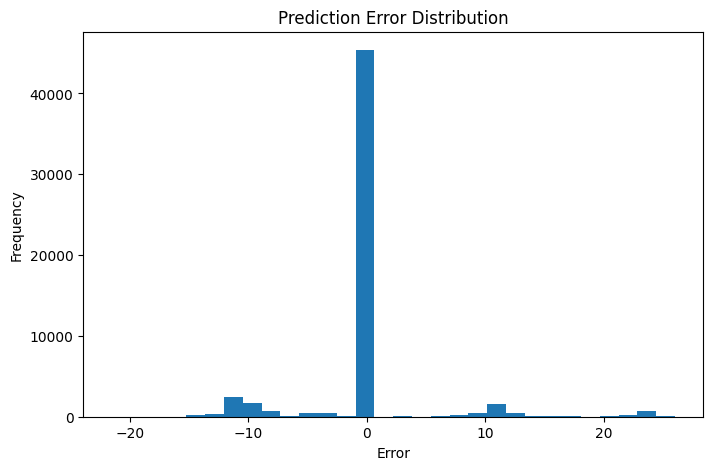

In [27]:
plt.figure(figsize=(8, 5))
plt.hist(error_df["error"], bins=30)
plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()